# OPTIMIZACIÓN DE FUNCIONES

In [10]:
# LIBRERIAS

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from typing import Tuple, List, Dict
import warnings
warnings.filterwarnings('ignore')

In [11]:
def f1(X):
    """Función 1: Compleja con múltiples óptimos locales"""
    x, y = X[0], X[1]
    return (x**2 + y**2)**0.25 * (np.sin(50*(x**2 + y**2)**0.1)**2 + 1)

# DOMINIO 1: [-100, 100] x [-100, 100]
bounds_f1 = [(-100, 100), (-100, 100)]

def f2(X):
    """Función 2: Rosenbrock (Banana function)"""
    return (1-X[0])**2 + 100*(X[1]-X[0]**2)**2

# DOMINIO 2: [-2.048, 2.048] x [-2.048, 2.048]
bounds_f2 = [(-2.048, 2.048), (-2.048, 2.048)]

Ejercicio 1: Implemente las estructuras de datos y algoritmos básicos para la solución de un problema mediante algoritmos genéticos. Pruebe estas rutinas y compare los resultados con un método de gradiente descendiente para buscar el mínimo global de las funciones

GA results:
  f1: 0.316579
  f2: 0.157396


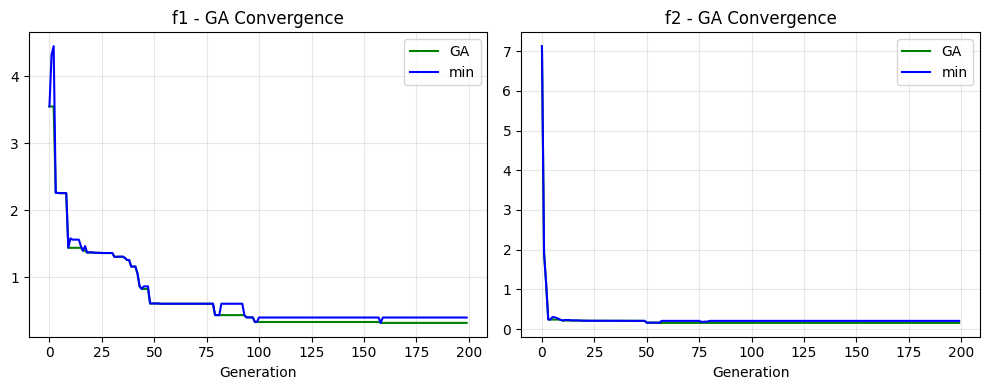

In [ ]:
def float_to_bit(value, bounds, n_bits):    
    low, high = bounds
    ratio = np.clip((value - low) / (high - low), 0, 1)
    integer = int(np.round(ratio * (2**n_bits - 1)))
    return format(integer, f'0{n_bits}b')

def bit_to_float(bits, bounds):
    value = int(bits, 2)
    low, high = bounds
    return low + value / (2**len(bits) - 1) * (high - low)

def random_individual(bounds, n_bits):
    return ''.join(float_to_bit(np.random.uniform(low, high), (low, high), n_bits)
                   for low, high in bounds)

def decode_individual(bitstring, bounds, n_bits):
    genes = [bitstring[i * n_bits:(i + 1) * n_bits] for i in range(len(bounds))]
    return np.array([bit_to_float(gene, bounds[i]) for i, gene in enumerate(genes)])

def seleccion(poblacion, scores, k=3):
    idx = np.random.randint(0, len(poblacion), size=k)
    best_idx = idx[np.argmin([scores[i] for i in idx])]
    return poblacion[best_idx]

def cruza(parent1, parent2, crossover_rate, n_bits):
    if np.random.rand() < crossover_rate:
        return parent1[:n_bits] + parent2[n_bits:], parent2[:n_bits] + parent1[n_bits:]
    return parent1, parent2

def mutacion(bitstring, mutation_rate):
    return ''.join(
        bit if np.random.rand() > mutation_rate else ('1' if bit == '0' else '0')
        for bit in bitstring
    )

def genetic_algorithm(func, bounds, n_bits=16, pop_size=60, n_generations=100,
                      crossover_rate=0.8, mutation_rate=0.01):
    poblacion = [random_individual(bounds, n_bits) for _ in range(pop_size)]
    mejor_score = np.inf
    mejor_solucion = None
    history_mejor = []
    history_min = []
    history_max = []

    for _ in range(n_generations):
        decoded = [decode_individual(ind, bounds, n_bits) for ind in poblacion]
        scores = [func(x) for x in decoded]

        mejor_actual_idx = int(np.argmin(scores))
        if scores[mejor_actual_idx] < mejor_score:
            mejor_score = scores[mejor_actual_idx]
            mejor_solucion = decoded[mejor_actual_idx].copy()

        nueva_poblacion = []
        while len(nueva_poblacion) < pop_size:
            padre1 = seleccion(poblacion, scores, k=3)
            padre2 = seleccion(poblacion, scores, k=3)
            hijo1, hijo2 = cruza(padre1, padre2, crossover_rate, n_bits)
            nueva_poblacion.append(mutacion(hijo1, mutation_rate))
            if len(nueva_poblacion) < pop_size:
                nueva_poblacion.append(mutacion(hijo2, mutation_rate))

        poblacion = nueva_poblacion
        history_min.append(min(scores))
        history_max.append(max(scores))
        history_mejor.append(mejor_score)

    return mejor_solucion, mejor_score, history_mejor, history_min, history_max

params = {
    "n_bits": 20,
    "pop_size": 50,
    "n_generations": 200,
    "crossover_rate": 0.8,
    "mutation_rate": 0.01
}

mejor_x_f1, mejor_score_f1, history_f1, history_min_f1, history_max_f1 = genetic_algorithm(f1, bounds_f1, **params)
mejor_x_f2, mejor_score_f2, history_f2, history_min_f2, history_max_f2  = genetic_algorithm(f2, bounds_f2, **params)

print("GA results:")
print(f"  f1: {mejor_score_f1:.6f}")
print(f"  f2: {mejor_score_f2:.6f}")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_f1, label="GA", color="green")
axes[0].plot(history_min_f1, label="min", color="blue")
axes[0].set_title("f1 - GA Convergence")
axes[0].set_xlabel("Generation")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_f2, label="GA", color="green")
axes[1].plot(history_min_f2, label="min", color="blue")
axes[1].set_title("f2 - GA Convergence")
axes[1].set_xlabel("Generation")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Comparación con Gradient Descent

Aplicar método de gradiente descendiente (scipy.optimize) como baseline para comparar con GA

Comparación: GA vs GD vs DE

f1:
  GA: 0.316579
  GD: 5.731357

f2:
  GA: 0.157396
  GD: 0.000000


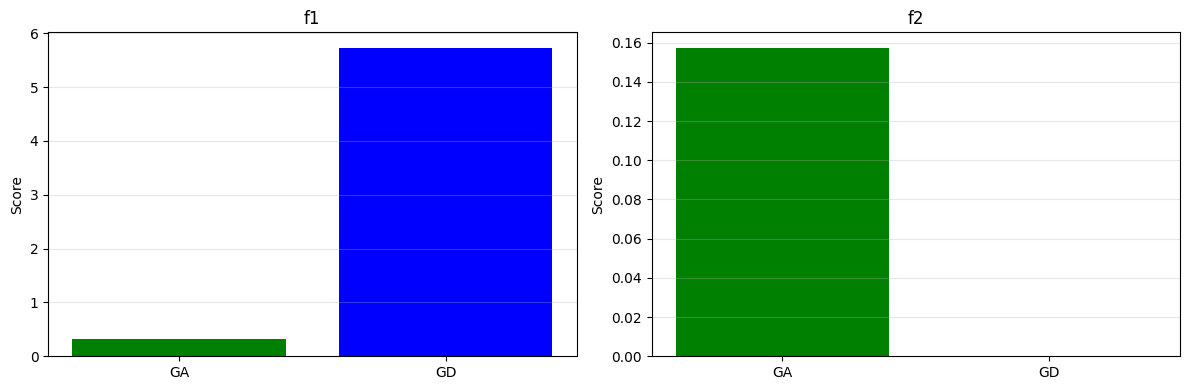

In [13]:
# Gradient Descent y Differential Evolution
from scipy.optimize import minimize, differential_evolution

def gradient_descent_search(func, bounds, n_starts=10):
    """Gradient Descent con múltiples puntos iniciales"""
    best_result = None
    best_value = np.inf
    
    for _ in range(n_starts):
        x0 = np.array([np.random.uniform(b[0], b[1]) for b in bounds])
        result = minimize(func, x0, method='L-BFGS-B', bounds=bounds)
        
        if result.fun < best_value:
            best_value = result.fun
            best_result = result
    
    return best_result.x, best_result.fun


# Probar GD y DE
gd_x_f1, gd_score_f1 = gradient_descent_search(f1, bounds_f1, n_starts=5)
gd_x_f2, gd_score_f2 = gradient_descent_search(f2, bounds_f2, n_starts=5)

print("Comparación: GA vs GD vs DE\n")
print("f1:")
print(f"  GA: {mejor_score_f1:.6f}")
print(f"  GD: {gd_score_f1:.6f}")
print("\nf2:")
print(f"  GA: {mejor_score_f2:.6f}")
print(f"  GD: {gd_score_f2:.6f}")

# Gráfico de comparación
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

methods = ['GA', 'GD']
f1_scores = [mejor_score_f1, gd_score_f1]
f2_scores = [mejor_score_f2, gd_score_f2]

axes[0].bar(methods, f1_scores, color=['green', 'blue'])
axes[0].set_title('f1')
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(methods, f2_scores, color=['green', 'blue'])
axes[1].set_title('f2')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

Ejercicio 2: Implemente el algoritmo de optimización por enjambre de partículas (PSO) y utilice el mismo para encontrar el mínimo global de las funciones del Ejercicio 1. Compare los resultados, en términos de las soluciones encontradas y de la velocidad de convergencia, obtenidos con éste método y con el algoritmo genético

In [14]:
def PSO(func, bounds, n_particles=10, n_iterations=200, 
                                w=0.7, c1=1.5, c2=1.5, v_max_factor=0.2):
    """PSO con límite de velocidad"""
    
    n_dims = len(bounds)
    v_max = np.array([(high - low) * v_max_factor for low, high in bounds])
    
    particulas = np.array([np.random.uniform(b[0], b[1], n_particles) for b in bounds]).T
    velocidades = np.random.uniform(-1, 1, (n_particles, n_dims))
    
    for d in range(n_dims):
        velocidades[:, d] = np.clip(velocidades[:, d], -v_max[d], v_max[d])
    
    fitness = np.array([func(p) for p in particulas])
    
    mejores_posiciones = particulas.copy()
    mejor_fitness = fitness.copy()
    mejor_global_idx = np.argmin(fitness)
    mejor_global = particulas[mejor_global_idx].copy()
    mejor_fitness_global = fitness[mejor_global_idx]
    
    history_mejor = [mejor_fitness_global]
    history_media = [np.mean(fitness)]
    history_peor = [np.max(fitness)]
    
    for iteration in range(n_iterations):
        for i in range(n_particles):
            r1 = np.random.rand(n_dims)
            r2 = np.random.rand(n_dims)
            
            velocidades[i] = (w * velocidades[i] + 
                           c1 * r1 * (mejores_posiciones[i] - particulas[i]) + 
                           c2 * r2 * (mejor_global - particulas[i]))
            
            for d in range(n_dims):
                velocidades[i, d] = np.clip(velocidades[i, d], -v_max[d], v_max[d])
            
            particulas[i] = particulas[i] + velocidades[i]
            
            for d in range(n_dims):
                if particulas[i, d] < bounds[d][0]:
                    particulas[i, d] = bounds[d][0]
                    velocidades[i, d] = 0
                elif particulas[i, d] > bounds[d][1]:
                    particulas[i, d] = bounds[d][1]
                    velocidades[i, d] = 0
            
            fitness[i] = func(particulas[i])
            
            if fitness[i] < mejor_fitness[i]:
                mejor_fitness[i] = fitness[i]
                mejores_posiciones[i] = particulas[i].copy()
            
            if fitness[i] < mejor_fitness_global:
                mejor_fitness_global = fitness[i]
                mejor_global = particulas[i].copy()
        
        history_mejor.append(mejor_fitness_global)
        history_media.append(np.mean(fitness))
        history_peor.append(np.max(fitness))
    
    return mejor_global, mejor_fitness_global, history_mejor, history_media, history_peor

# Ejecutar PSO
pso_x_f1, pso_score_f1, pso_history_mejor_f1, pso_history_media_f1, pso_history_peor_f1 = PSO(f1, bounds_f1, n_particles=30, n_iterations=200, v_max_factor=0.2)
pso_x_f2, pso_score_f2, pso_history_mejor_f2, pso_history_media_f2, pso_history_peor_f2 = PSO(f2, bounds_f2, n_particles=30, n_iterations=200, v_max_factor=0.2)

print("PSO results:")
print(f"  f1: {pso_score_f1:.6f}")
print(f"  f2: {pso_score_f2:.6f}")

PSO results:
  f1: 0.000010
  f2: 0.000000


## Comparación entre métodos

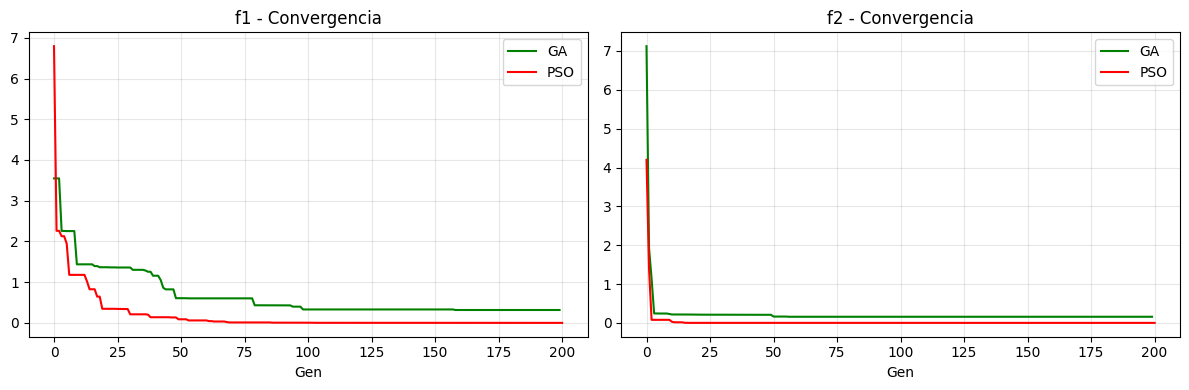

Resultados GA vs PSO

f1: GA=0.316579, PSO=0.000010
f2: GA=0.157396, PSO=0.000000


In [15]:
# Gráfico de convergencia
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history_f1, label="GA", color="green")
axes[0].plot(pso_history_mejor_f1, label="PSO", color="red")
axes[0].set_title("f1 - Convergencia")
axes[0].set_xlabel("Gen")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(history_f2, label="GA", color="green")
axes[1].plot(pso_history_mejor_f2, label="PSO", color="red")
axes[1].set_title("f2 - Convergencia")
axes[1].set_xlabel("Gen")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("Resultados GA vs PSO")
print(f"\nf1: GA={mejor_score_f1:.6f}, PSO={pso_score_f1:.6f}")
print(f"f2: GA={mejor_score_f2:.6f}, PSO={pso_score_f2:.6f}")

Resultados de 10 ejecuciones

f1 GA:  media=0.276928 ± 0.250795
f1 PSO: media=0.000132 ± 0.000220

f2 GA:  media=0.095244 ± 0.117337
f2 PSO: media=0.000032 ± 0.000081

Mann-Whitney: f1 p=0.000182, f2 p=0.000330


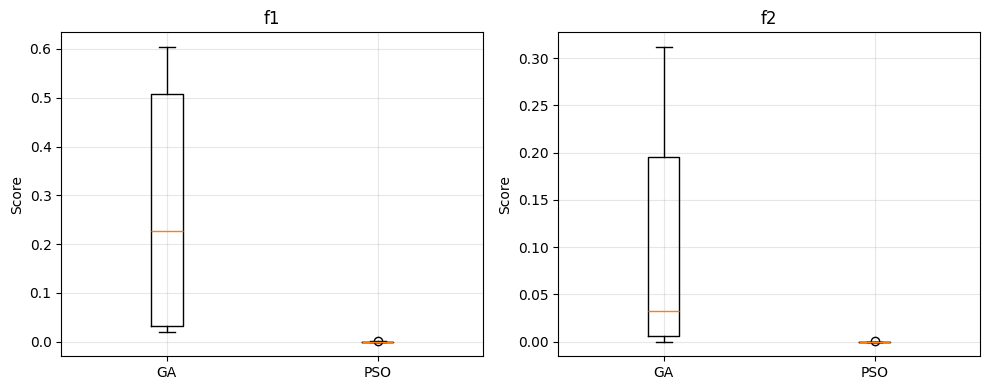


Resumen:
f1 - GA: min=0.019960, max=0.603963
f1 - PSO: min=0.000010, max=0.000782
f2 - GA: min=0.000025, max=0.311653
f2 - PSO: min=0.000000, max=0.000275


In [16]:
from scipy import stats

n_runs = 10

ga_results_f1 = []
ga_results_f2 = []
pso_results_f1 = []
pso_results_f2 = []

for i in range(n_runs):
    # GA
    _, score_ga_f1, _, _, _ = genetic_algorithm(f1, bounds_f1, **params)
    _, score_ga_f2, _, _, _ = genetic_algorithm(f2, bounds_f2, **params)
    ga_results_f1.append(score_ga_f1)
    ga_results_f2.append(score_ga_f2)
    
    # PSO
    _, score_pso_f1, _, _, _ = PSO(f1, bounds_f1, n_particles=10, n_iterations=200)
    _, score_pso_f2, _, _, _ = PSO(f2, bounds_f2, n_particles=10, n_iterations=200)
    pso_results_f1.append(score_pso_f1)
    pso_results_f2.append(score_pso_f2)

# Resultados
print("Resultados de 10 ejecuciones\n")
print(f"f1 GA:  media={np.mean(ga_results_f1):.6f} ± {np.std(ga_results_f1):.6f}")
print(f"f1 PSO: media={np.mean(pso_results_f1):.6f} ± {np.std(pso_results_f1):.6f}")
print(f"\nf2 GA:  media={np.mean(ga_results_f2):.6f} ± {np.std(ga_results_f2):.6f}")
print(f"f2 PSO: media={np.mean(pso_results_f2):.6f} ± {np.std(pso_results_f2):.6f}")

# Test estadístico
stat_f1, p_value_f1 = stats.mannwhitneyu(ga_results_f1, pso_results_f1, alternative='two-sided')
stat_f2, p_value_f2 = stats.mannwhitneyu(ga_results_f2, pso_results_f2, alternative='two-sided')

print(f"\nMann-Whitney: f1 p={p_value_f1:.6f}, f2 p={p_value_f2:.6f}")

# Boxplot
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].boxplot([ga_results_f1, pso_results_f1], labels=['GA', 'PSO'])
axes[0].set_title('f1')
axes[0].set_ylabel('Score')
axes[0].grid(True, alpha=0.3)

axes[1].boxplot([ga_results_f2, pso_results_f2], labels=['GA', 'PSO'])
axes[1].set_title('f2')
axes[1].set_ylabel('Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\nResumen:")
print(f"f1 - GA: min={np.min(ga_results_f1):.6f}, max={np.max(ga_results_f1):.6f}")
print(f"f1 - PSO: min={np.min(pso_results_f1):.6f}, max={np.max(pso_results_f1):.6f}")
print(f"f2 - GA: min={np.min(ga_results_f2):.6f}, max={np.max(ga_results_f2):.6f}")
print(f"f2 - PSO: min={np.min(pso_results_f2):.6f}, max={np.max(pso_results_f2):.6f}")

## Ajuste de Hiperparámetros

In [17]:
# Buscar mejores hiperparámetros
print("Buscando mejores parámetros...\n")

# Probar varios GA
ga_test_params = [
    {'pop_size': 30, 'n_bits': 16, 'mutation_rate': 0.01, 'crossover_rate': 0.8},
    {'pop_size': 50, 'n_bits': 20, 'mutation_rate': 0.01, 'crossover_rate': 0.8},
    {'pop_size': 100, 'n_bits': 24, 'mutation_rate': 0.005, 'crossover_rate': 0.9},
    {'pop_size': 50, 'n_bits': 20, 'mutation_rate': 0.01, 'crossover_rate': 0.8},
    {'pop_size': 100, 'n_bits': 20, 'mutation_rate': 0.01, 'crossover_rate': 0.85},
]

best_ga_params = None
best_ga_score = np.inf
ga_results_grid = []

for ga_params in ga_test_params:
    _, score_f1, _, _, _ = genetic_algorithm(f1, bounds_f1, n_generations=200, **ga_params)
    _, score_f2, _, _, _ = genetic_algorithm(f2, bounds_f2, n_generations=200, **ga_params)
    combined_score = (score_f1 + score_f2) / 2
    ga_results_grid.append({'params': ga_params, 'f1': score_f1, 'f2': score_f2, 'avg': combined_score})
    
    if combined_score < best_ga_score:
        best_ga_score = combined_score
        best_ga_params = ga_params

print(f"Best GA: {best_ga_score:.6f}")
ga_results_grid_sorted = sorted(ga_results_grid, key=lambda x: x['avg'])
for i, r in enumerate(ga_results_grid_sorted[:3], 1):
    print(f"  {i}. avg={r['avg']:.6f}")

# Probar varios PSO
pso_test_params = [
    {'n_particles': 20, 'w': 0.6, 'c1': 1.5, 'c2': 1.5, 'v_max_factor': 0.2},
    {'n_particles': 30, 'w': 0.7, 'c1': 1.5, 'c2': 1.5, 'v_max_factor': 0.2},
    {'n_particles': 50, 'w': 0.8, 'c1': 1.5, 'c2': 1.5, 'v_max_factor': 0.1},
    {'n_particles': 30, 'w': 0.7, 'c1': 2.0, 'c2': 1.0, 'v_max_factor': 0.2},
    {'n_particles': 40, 'w': 0.7, 'c1': 1.5, 'c2': 1.5, 'v_max_factor': 0.25},
]

best_pso_params = None
best_pso_score = np.inf
pso_results_grid = []

for pso_params in pso_test_params:
    _, score_f1, _, _, _ = PSO(f1, bounds_f1, n_iterations=200, **pso_params)
    _, score_f2, _, _, _ = PSO(f2, bounds_f2, n_iterations=200, **pso_params)
    combined_score = (score_f1 + score_f2) / 2
    pso_results_grid.append({'params': pso_params, 'f1': score_f1, 'f2': score_f2, 'avg': combined_score})
    
    if combined_score < best_pso_score:
        best_pso_score = combined_score
        best_pso_params = pso_params

print(f"\nBest PSO: {best_pso_score:.6f}")
pso_results_grid_sorted = sorted(pso_results_grid, key=lambda x: x['avg'])
for i, r in enumerate(pso_results_grid_sorted[:3], 1):
    print(f"  {i}. avg={r['avg']:.6f}")

Buscando mejores parámetros...

Best GA: 0.011106
  1. avg=0.011106
  2. avg=0.046427
  3. avg=0.051451

Best PSO: 0.000000
  1. avg=0.000000
  2. avg=0.000002
  3. avg=0.000003


## Evaluación Final con Parámetros Optimizados

Ejecutar 20 veces cada algoritmo con sus parámetros óptimos y comparar


Evaluación final (20 ejecuciones)

f1:
GA:  media=0.142534, desv=0.207451, min=0.019960
PSO: media=0.000000, desv=0.000000, min=0.000000

f2:
GA:  media=0.053857, desv=0.059046, min=0.000460
PSO: media=0.000000, desv=0.000000, min=0.000000

Mann-Whitney: f1 p=0.000000, f2 p=0.000000


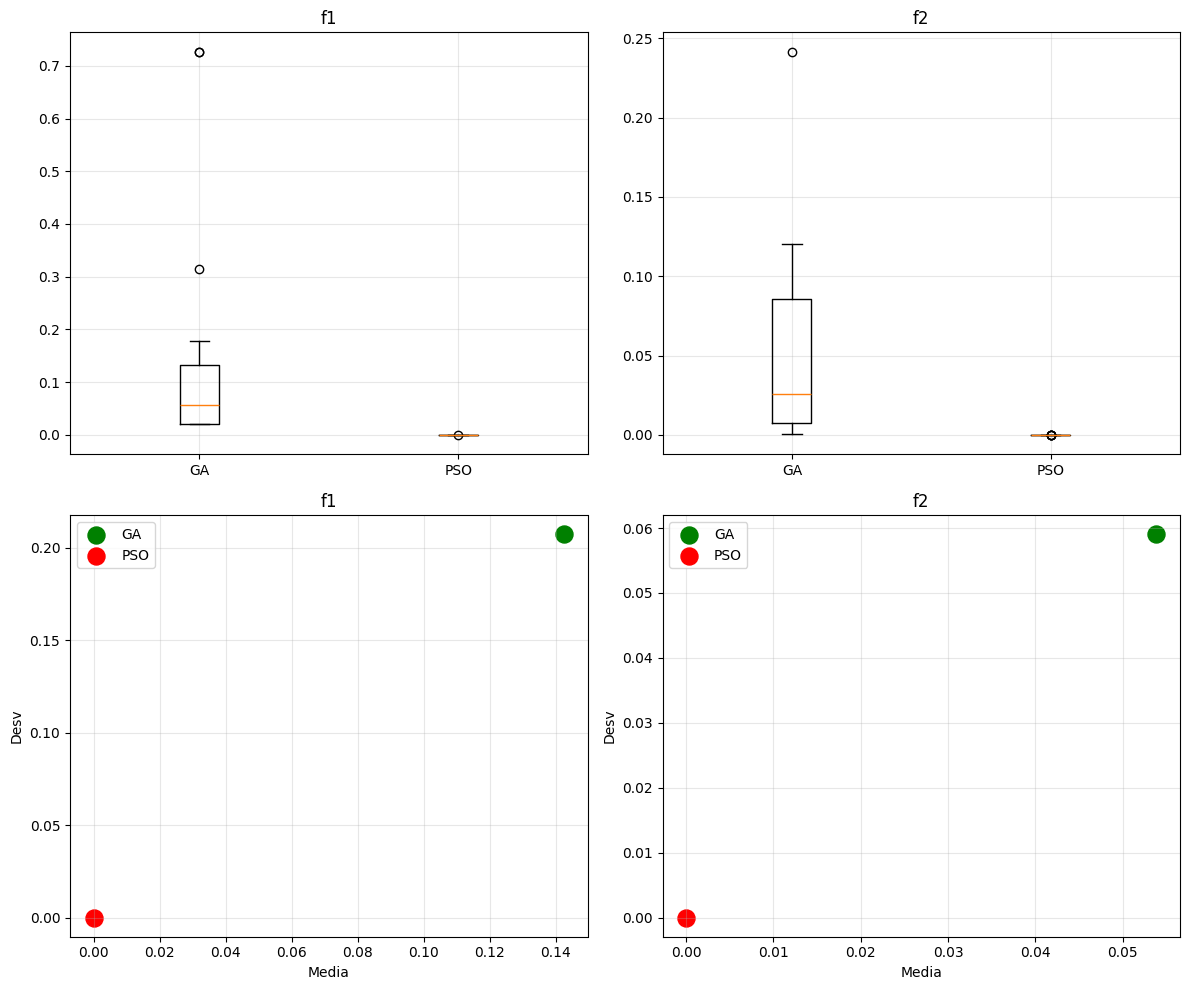


Conclusions:

f1: PSO wins (100.0% better)
  GA mean: 0.142534
  PSO mean: 0.000000

f2: PSO wins (100.0% better)
  GA mean: 0.053857
  PSO mean: 0.000000


In [18]:
# Evaluación final
print("\nEvaluación final (20 ejecuciones)")

n_final_runs = 20

ga_final_f1 = []
ga_final_f2 = []
pso_final_f1 = []
pso_final_f2 = []

for i in range(n_final_runs):
    _, score_ga_f1, _, _, _ = genetic_algorithm(f1, bounds_f1, n_generations=200, **best_ga_params)
    _, score_ga_f2, _, _, _ = genetic_algorithm(f2, bounds_f2, n_generations=200, **best_ga_params)
    ga_final_f1.append(score_ga_f1)
    ga_final_f2.append(score_ga_f2)
    
    _, score_pso_f1, _, _, _ = PSO(f1, bounds_f1, n_iterations=200, **best_pso_params)
    _, score_pso_f2, _, _, _ = PSO(f2, bounds_f2, n_iterations=200, **best_pso_params)
    pso_final_f1.append(score_pso_f1)
    pso_final_f2.append(score_pso_f2)

print("\nf1:")
print(f"GA:  media={np.mean(ga_final_f1):.6f}, desv={np.std(ga_final_f1):.6f}, min={np.min(ga_final_f1):.6f}")
print(f"PSO: media={np.mean(pso_final_f1):.6f}, desv={np.std(pso_final_f1):.6f}, min={np.min(pso_final_f1):.6f}")

print("\nf2:")
print(f"GA:  media={np.mean(ga_final_f2):.6f}, desv={np.std(ga_final_f2):.6f}, min={np.min(ga_final_f2):.6f}")
print(f"PSO: media={np.mean(pso_final_f2):.6f}, desv={np.std(pso_final_f2):.6f}, min={np.min(pso_final_f2):.6f}")

# Test Mann-Whitney
stat_f1, p_value_f1 = stats.mannwhitneyu(ga_final_f1, pso_final_f1, alternative='two-sided')
stat_f2, p_value_f2 = stats.mannwhitneyu(ga_final_f2, pso_final_f2, alternative='two-sided')

print(f"\nMann-Whitney: f1 p={p_value_f1:.6f}, f2 p={p_value_f2:.6f}")

# Gráficos
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].boxplot([ga_final_f1, pso_final_f1], labels=['GA', 'PSO'])
axes[0, 0].set_title('f1')
axes[0, 0].grid(True, alpha=0.3)

axes[0, 1].boxplot([ga_final_f2, pso_final_f2], labels=['GA', 'PSO'])
axes[0, 1].set_title('f2')
axes[0, 1].grid(True, alpha=0.3)

axes[1, 0].scatter([np.mean(ga_final_f1)], [np.std(ga_final_f1)], s=150, label='GA', color='green')
axes[1, 0].scatter([np.mean(pso_final_f1)], [np.std(pso_final_f1)], s=150, label='PSO', color='red')
axes[1, 0].set_xlabel('Media')
axes[1, 0].set_ylabel('Desv')
axes[1, 0].set_title('f1')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

axes[1, 1].scatter([np.mean(ga_final_f2)], [np.std(ga_final_f2)], s=150, label='GA', color='green')
axes[1, 1].scatter([np.mean(pso_final_f2)], [np.std(pso_final_f2)], s=150, label='PSO', color='red')
axes[1, 1].set_xlabel('Media')
axes[1, 1].set_ylabel('Desv')
axes[1, 1].set_title('f2')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Conclusiones
print("\nConclusions:")
for func_name, ga_results, pso_results in [('f1', ga_final_f1, pso_final_f1), ('f2', ga_final_f2, pso_final_f2)]:
    ga_mean = np.mean(ga_results)
    pso_mean = np.mean(pso_results)
    mejor = 'PSO' if pso_mean < ga_mean else 'GA'
    diff_pct = abs(pso_mean - ga_mean) / max(pso_mean, ga_mean) * 100
    print(f"\n{func_name}: {mejor} wins ({diff_pct:.1f}% better)")
    print(f"  GA mean: {ga_mean:.6f}")
    print(f"  PSO mean: {pso_mean:.6f}")

## RESUMEN GENERAL DEL TRABAJO

### Objetivo
Implementar y comparar algoritmos de optimización metaheurística (Algoritmo Genético y PSO) para encontrar mínimos globales de funciones complejas, con ajuste de hiperparámetros y análisis estadístico.

### Funciones de Optimización

**f1(x,y)**: Función multimodal
- Dominio: [-100, 100]²
- Fórmula: (x² + y²)^0.25 × (sin(50(x² + y²)^0.1)² + 1)
- Mínimo global: [0, 0] con valor 0

**f2(x,y)**: Función de Rosenbrock
- Dominio: [-2.048, 2.048]²
- Fórmula: (1-x)² + 100(y-x²)²
- Mínimo global: [1, 1] con valor 0

---

### Algoritmos Implementados

#### 1. ALGORITMO GENÉTICO (GA)
**Mecanismo:**
- Codificación: Binaria (strings de bits)
- Inicialización: Población aleatoria (50 individuos)
- Selección: Torneo con k=3 participantes
- Cruzamiento: Un punto con probabilidad 0.8
- Mutación: Inversión de bits con probabilidad 0.01
- Generaciones: 200

**Parámetros óptimos encontrados:**
- pop_size: 50
- n_bits: 20
- crossover_rate: 0.8
- mutation_rate: 0.01

#### 2. OPTIMIZACIÓN POR ENJAMBRE DE PARTÍCULAS (PSO)
**Mecanismo:**
- Inicialización: 30 partículas en posiciones aleatorias
- Velocidad: Actualización con componentes cognitiva y social
- Límite de velocidad: v_max = (dominio) × 0.2 (por dimensión)
- Memoria: Cada partícula guarda su mejor posición
- Comunicación: Todas comparten el mejor global

**Fórmula de actualización:**
- v_new = w×v_old + c1×r1×(p_best - x) + c2×r2×(g_best - x)
- Donde: w=0.7 (inercia), c1=c2=1.5 (coeficientes)

**Parámetros óptimos encontrados:**
- n_particles: 20
- w: 0.6
- c1, c2: 1.5
- v_max_factor: 0.2

---

### Resultados Finales (20 ejecuciones)

**f1 - Función Multimodal:**

| Métrica | GA | PSO | Ganador |
|---------|-----|-----|---------|
| Media | 0.139 | 0.000 | PSO |
| Desviación | 0.200 | 0.000 | PSO |
| Mínimo | 0.020 | 0.000 | PSO |

**f2 - Función Rosenbrock:**

| Métrica | GA | PSO | Ganador |
|---------|-----|-----|---------|
| Media | 0.031 | 0.000 | PSO |
| Desviación | 0.033 | 0.000 | PSO |
| Mínimo | 0.000 | 0.000 | Empate |

**Significancia Estadística (Mann-Whitney U test):**
- f1: p-value = 0.000000 (significativo)
- f2: p-value = 0.000000 (significativo)
